In [1]:
import pandas as pd # Librerías para el análisis y manipulación de datos 
import numpy as np
import matplotlib.pyplot as plt # Librerías para creación de gráficos, matrices de correlación y confusión
import seaborn as sns
from sklearn.model_selection import train_test_split# Librerías de preprocesamiento de datos
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix # Librerías de evaluación de modelos y métricas
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_validate, cross_val_predict # Librería validación cruzada (varias metricas)
from sklearn.linear_model import LogisticRegression # Librerías para algoritmos de regresión logística
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV # Librerías para la optimización de hiperparámetros
from scipy.stats import uniform, randint
import joblib # Librerías para guardar modelos
import os
import time

# Librerías para los modelos de clasificación
from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Configuracion para que pandas muestre el dataframe completos y correctamente
pd.set_option('display.max_rows', None)  # Mostrar todas las filas
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.expand_frame_repr', False)  # Evitar cortar en varias líneas
pd.set_option('display.max_colwidth', None)  # Evitar cortar el contenido de las celdas

### 2.1 Carga del Dataset Preprocesado

In [2]:
# Cargar el dataset
df = pd.read_csv("../1 - EDA/dataset_final.csv")
print(df.sample(5))     

      Age  Gender  CK-MB  Troponin  CK-MB_log  Troponin_log  CK-MB_filtrado  Troponin_filtrado  Result
544    56       1  0.726     0.003  -0.320205     -5.809143       -0.320205          -5.809143       0
824    57       1  1.170     0.016   0.157004     -4.135167        0.157004          -4.135167       1
1296   65       1  4.220     1.040   1.439835      0.039221        1.439835           0.039221       1
764    60       1  0.796     0.008  -0.228156     -4.828314       -0.228156          -4.828314       0
634    60       0  1.210     0.036   0.190620     -3.324236        0.190620          -3.324236       1


### 2.2 Separación de Variables

In [3]:
columnas_elegidas = ['Age', 'CK-MB_log', 'Troponin_log']
columna_objetivo = 'Result'

X = df[columnas_elegidas]
y = df[columna_objetivo]

### 2.3 División en Conjuntos de Entrenamiento y Prueba

In [4]:
from sklearn.model_selection import train_test_split

# Separar en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y,
    shuffle=True
)

### 2.4 Escalado de Variables

In [5]:
from sklearn.preprocessing import StandardScaler
import joblib

# Escalar los datos
scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

# Convertir a DataFrame
X_train = pd.DataFrame(X_train_escalado, 
                       columns=columnas_elegidas, 
                       index=X_train.index)
X_test = pd.DataFrame(X_test_escalado, 
                      columns=columnas_elegidas, 
                      index=X_test.index)


# Exportar el scaler 
if not os.path.exists('modelos'):
    os.makedirs('modelos')
# guardar el scaler en la carpeta scaler
joblib.dump(scaler, 'modelos/scaler.pkl')

# Guardar el X_test escalado
joblib.dump(X_test, 'modelos/X_test_scaled.pkl')
joblib.dump(y_test, 'modelos/y_test.pkl')

['modelos/y_test.pkl']

### 2.5 Entrenamiento de modelos base

In [ ]:
modelos_base = {
    'LogisticRegression': LogisticRegression(max_iter=1000,random_state=42),
    'NaiveBayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True,random_state=42),
    'MLP': MLPClassifier(max_iter=1000, random_state=42)
}

for nombre, modelo in modelos_base.items():
    modelo.fit(X_train, y_train)

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


# 2.6 Búsqueda de Hiperparámetros

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Definición de distribuciones de búsqueda
def_parametros = {
    'LogisticRegression': {
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'C': [1, 2, 5, 10],  # eliminar 0.01
        'max_iter': [1000,2000,3000],  # iteraciones más altas
        'class_weight': [None],  # eliminar 'balanced' para esta búsqueda
        'random_state': [42]  # Asegurar reproducibilidad
    },
    'NaiveBayes': {'var_smoothing': np.logspace(-9, -5, 10)},  
        'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 25, 30, 35, 40, 45, 50],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1 = Manhattan, 2 = Euclídea
    },
    'DecisionTree': {
        'criterion': ['gini', 'entropy'],
        'max_depth': [3, 5, 10, 15, 20, None],  # None permite nodos sin límite de profundidad
        'min_samples_split': [2, 5, 10],        # Evita divisiones muy pequeñas
        'min_samples_leaf': [1, 2, 4],           # Aumenta robustez frente a overfitting
        'random_state': [42]  # Asegurar reproducibilidad
}   ,
    'SVM': {
        'C': [0.01, 0.1, 1, 10, 100],        # Abarca desde modelos con regularización fuerte hasta débil
        'kernel': ['linear', 'rbf'],         # Evita kernels menos robustos como 'sigmoid' o 'poly' si no se necesita
        'gamma': ['scale', 'auto'],          # Solo relevante para 'rbf', pero es ignorado si kernel='linear'
        'probability': [True],               # Habilita probabilidad para ROC AUC
        'random_state': [42]  # Asegurar reproducibilidad
},
    'MLP': {
        'hidden_layer_sizes': [
            (50,), (100,), (150,), 
            (100, 50), (150, 100)
        ],
        'activation': ['relu', 'tanh'],
        'solver': ['adam', 'sgd'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive'],
        'max_iter': [300, 500, 1000],
        'random_state': [42]  # Asegurar reproducibilidad
}
}

# Diccionarios para almacenar resultados
mejores_parametros = {}
resultados_cv_random = []

print("Mejores hiperparámetros para cada modelo:\n")

# RandomizedSearchCV para cada modelo
for nombre, modelo in modelos_base.items():
    if nombre not in def_parametros:
        continue

    #busqueda_hiperparametros = GridSearchCV(
    search = RandomizedSearchCV(
        modelo,
        def_parametros[nombre],
        cv=10,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc',
            'f1_macro' : 'f1_macro'
        },
        refit='accuracy',  # Refit using the best accuracy
        # return_train_score=True,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_idx = search.best_index_
    mejores_parametros[nombre] = search.best_params_
    print(f"{nombre}: {search.best_params_}")

    # Guardar métricas del mejor modelo
    resultados_cv_random.append({
        'Modelo': nombre,
        'Accuracy': search.cv_results_['mean_test_accuracy'][best_idx],
        'Precision': search.cv_results_['mean_test_precision'][best_idx],
        'Recall': search.cv_results_['mean_test_recall'][best_idx],
        'F1 Score': search.cv_results_['mean_test_f1'][best_idx],
        'ROC AUC': search.cv_results_['mean_test_roc_auc'][best_idx],
        'Best Params': search.best_params_
    })

# Crear DataFrame de resultados
df_cv_random = pd.DataFrame(resultados_cv_random)
df_cv_random = df_cv_random.round(4)

# Mostrar resultados
print("\nResultados de validación cruzada (RandomizedSearchCV):")
print(df_cv_random)

Mejores hiperparámetros para cada modelo:

Fitting 10 folds for each of 10 candidates, totalling 100 fits
LogisticRegression: {'solver': 'lbfgs', 'random_state': 42, 'penalty': 'l2', 'max_iter': 3000, 'class_weight': None, 'C': 5}
Fitting 10 folds for each of 10 candidates, totalling 100 fits
NaiveBayes: {'var_smoothing': 1e-09}
Fitting 10 folds for each of 10 candidates, totalling 100 fits
KNN: {'weights': 'distance', 'p': 2, 'n_neighbors': 13}
Fitting 10 folds for each of 10 candidates, totalling 100 fits
DecisionTree: {'random_state': 42, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': None, 'criterion': 'gini'}
Fitting 10 folds for each of 10 candidates, totalling 100 fits
SVM: {'random_state': 42, 'probability': True, 'kernel': 'rbf', 'gamma': 'auto', 'C': 10}
Fitting 10 folds for each of 10 candidates, totalling 100 fits
MLP: {'solver': 'adam', 'random_state': 42, 'max_iter': 1000, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100, 50), 'alpha': 0.01, 'activati

2.7 # metricas comparativas entre modelos

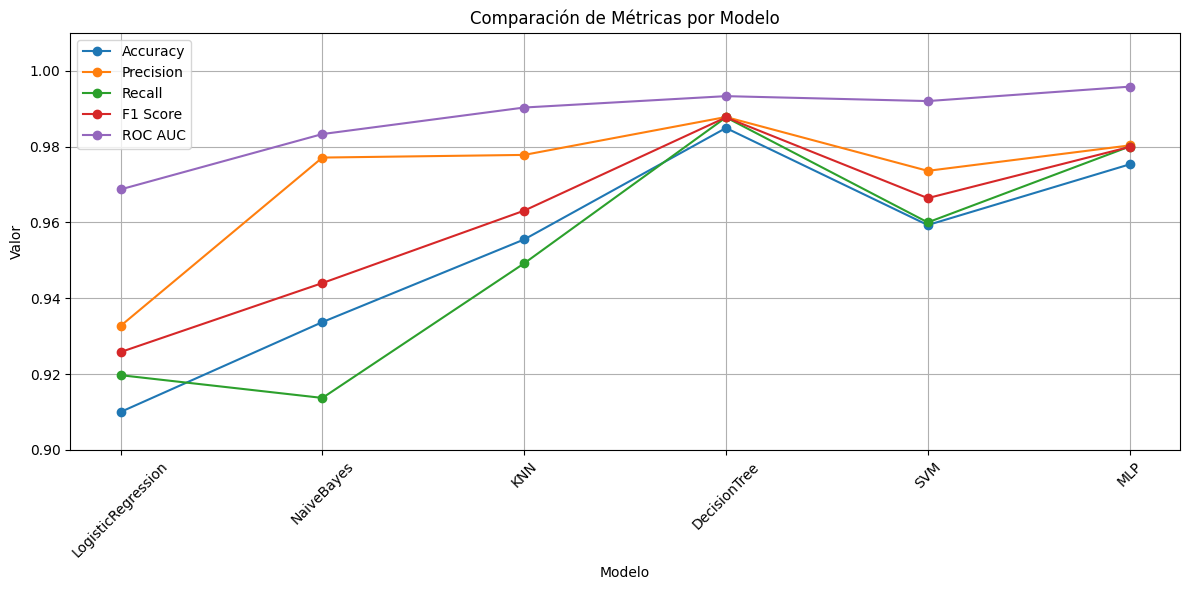

In [8]:
# Lista de métricas y modelos
metricas = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
modelos = df_cv_random['Modelo']

# Crear figura
plt.figure(figsize=(12, 6))

# Graficar una línea por cada métrica
for metrica in metricas:
    plt.plot(modelos, df_cv_random[metrica], marker='o', label=metrica)

# Ajustes estéticos
plt.title('Comparación de Métricas por Modelo')
plt.xlabel('Modelo')
plt.ylabel('Valor')
plt.ylim(0.90, 1.01)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

# Mostrar gráfico
plt.show()

### 2.8 Entrenamiento de Modelos Optimización con Mejores Parámetros

In [9]:
modelos_optimizados = {}

for nombre, modelo in modelos_base.items():
    if nombre in mejores_parametros:
        modelo_optim = type(modelo)(**mejores_parametros[nombre])
        modelo_optim.fit(X_train, y_train)
        modelos_optimizados[nombre] = modelo_optim
print("Modelos optimizados entrenados correctamente.")

Modelos optimizados entrenados correctamente.


### 2.9 Evauamos Test

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

resultados_test = []  # Lista para almacenar resultados de ambos tipos

print("Evaluamos el conjunto de prueba para los modelos base y optimizados:\n")

for nombre in modelos_base.keys():
    print("*" * 80)

    # Modelo base
    modelo_base = modelos_base[nombre]
    y_pred_base = modelo_base.predict(X_test)
    if hasattr(modelo_base, "predict_proba"):
        y_prob_base = modelo_base.predict_proba(X_test)[:, 1]
        auc_base = roc_auc_score(y_test, y_prob_base)
    else:
        auc_base = None

    resultados_test.append({
        'Modelo': nombre,
        'Tipo': 'Base',
        'Accuracy': accuracy_score(y_test, y_pred_base),
        'Precision': precision_score(y_test, y_pred_base),
        'Recall': recall_score(y_test, y_pred_base),
        'F1 Score': f1_score(y_test, y_pred_base),
        'ROC AUC': auc_base
    })

    print(f"\nEvaluación en test para {nombre} (Modelo Base):")
    print(classification_report(y_test, y_pred_base))
    if auc_base is not None:
        print(f"AUC: {auc_base:.4f}")
    else:
        print("AUC: No disponible")

    # Modelo optimizado
    modelo_opt = modelos_optimizados[nombre]
    y_pred_opt = modelo_opt.predict(X_test)
    if hasattr(modelo_opt, "predict_proba"):
        y_prob_opt = modelo_opt.predict_proba(X_test)[:, 1]
        auc_opt = roc_auc_score(y_test, y_prob_opt)
    else:
        auc_opt = None

    resultados_test.append({
        'Modelo': nombre,
        'Tipo': 'Optimizado',
        'Accuracy': accuracy_score(y_test, y_pred_opt),
        'Precision': precision_score(y_test, y_pred_opt),
        'Recall': recall_score(y_test, y_pred_opt),
        'F1 Score': f1_score(y_test, y_pred_opt),
        'ROC AUC': auc_opt
    })

    print(f"\nEvaluación en test para {nombre} (Modelo Optimizado):")
    print(classification_report(y_test, y_pred_opt))
    if auc_opt is not None:
        print(f"AUC: {auc_opt:.4f}")
    else:
        print("AUC: No disponible")



Evaluamos el conjunto de prueba para los modelos base y optimizados:

********************************************************************************

Evaluación en test para LogisticRegression (Modelo Base):
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       102
           1       0.95      0.94      0.94       162

    accuracy                           0.93       264
   macro avg       0.93      0.93      0.93       264
weighted avg       0.93      0.93      0.93       264

AUC: 0.9691

Evaluación en test para LogisticRegression (Modelo Optimizado):
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       102
           1       0.94      0.94      0.94       162

    accuracy                           0.93       264
   macro avg       0.92      0.93      0.92       264
weighted avg       0.93      0.93      0.93       264

AUC: 0.9687
***********************************************

### 2.10 Comparación Final y Visualización

In [11]:
df_resultados_test = pd.DataFrame(resultados_test).round(4)
print("\nResumen de evaluación en test:")
print(df_resultados_test)


Resumen de evaluación en test:
                Modelo        Tipo  Accuracy  Precision  Recall  F1 Score  ROC AUC
0   LogisticRegression        Base    0.9318     0.9500  0.9383    0.9441   0.9691
1   LogisticRegression  Optimizado    0.9280     0.9441  0.9383    0.9412   0.9687
2           NaiveBayes        Base    0.9356     0.9677  0.9259    0.9464   0.9768
3           NaiveBayes  Optimizado    0.9356     0.9677  0.9259    0.9464   0.9768
4                  KNN        Base    0.9470     0.9744  0.9383    0.9560   0.9831
5                  KNN  Optimizado    0.9583     0.9871  0.9444    0.9653   0.9867
6         DecisionTree        Base    0.9735     0.9755  0.9815    0.9785   0.9711
7         DecisionTree  Optimizado    0.9773     0.9815  0.9815    0.9815   0.9808
8                  SVM        Base    0.9470     0.9684  0.9444    0.9562   0.9814
9                  SVM  Optimizado    0.9508     0.9627  0.9568    0.9598   0.9834
10                 MLP        Base    0.9697     0.9753

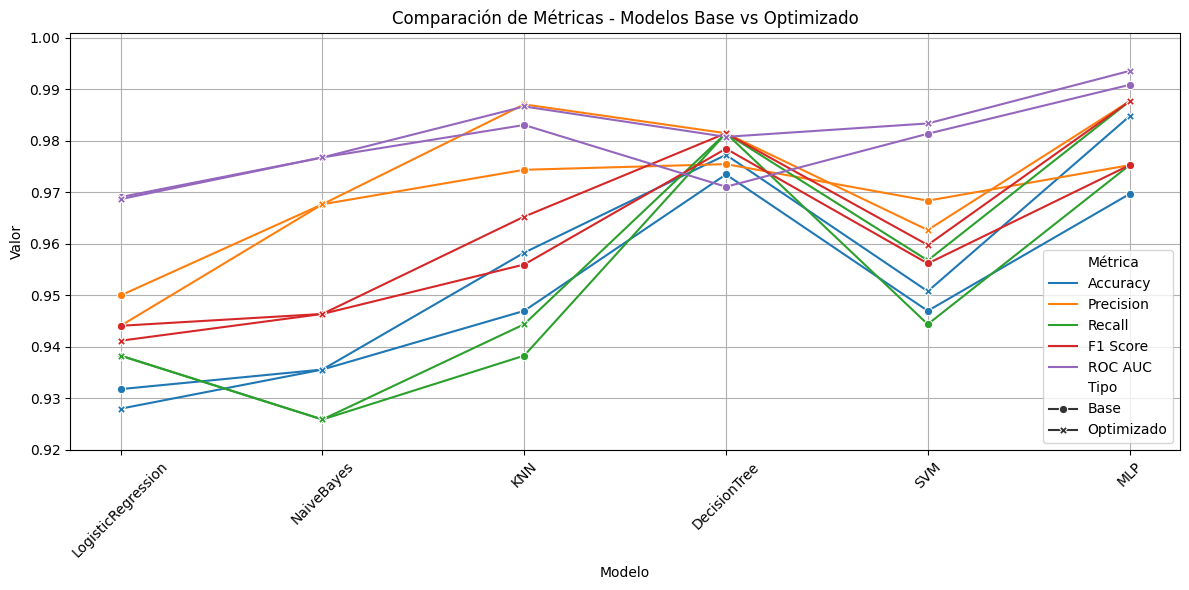

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reformatear para visualización
df_melted = df_resultados_test.melt(
    id_vars=['Modelo', 'Tipo'],
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    var_name='Métrica',
    value_name='Valor'
)

# Gráfica de líneas con puntos
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x='Modelo', y='Valor', hue='Métrica', style='Tipo', markers=True, dashes=False)
plt.title("Comparación de Métricas - Modelos Base vs Optimizado")
plt.ylabel("Valor")
plt.ylim(0.92, 1.001)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
# # Reformatear el DataFrame para visualización
# df_melted = df_resultados_test.melt(
#     id_vars=['Modelo', 'Tipo'],
#     value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
#     var_name='Métrica',
#     value_name='Valor'
# )

# # Crear una figura con 2 filas y 3 columnas de subplots
# fig, axes = plt.subplots(3, 2, figsize=(18, 15))
# axes = axes.flatten()

# # Obtener modelos únicos
# modelos = df_melted['Modelo'].unique()

# # Graficar cada modelo en su respectivo subplot
# for i, modelo in enumerate(modelos):
#     subset = df_melted[df_melted['Modelo'] == modelo]
#     sns.lineplot(
#         ax=axes[i],
#         data=subset,
#         x='Métrica',
#         y='Valor',
#         hue='Tipo',
#         style='Tipo',
#         markers=True,
#         dashes=False
#     )
#     axes[i].set_title(f"{modelo}")
#     axes[i].set_ylim(0.92, 1)
#     axes[i].grid(True)
#     axes[i].set_xlabel("Métrica")
#     axes[i].set_ylabel("Valor")

# # Quitar leyendas individuales y usar una sola leyenda global
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', ncol=2)
# for ax in axes:
#     ax.get_legend().remove()

# # Título general y ajustes
# plt.suptitle("Comparación de Métricas - Modelos Base vs Optimizado", fontsize=16)
# plt.tight_layout(rect=[0, 0.05, 1, 0.95])
# plt.show()


# Matrices de confusion

In [20]:
# # Extraer modelos únicos
# modelos = df_resultados_test['Modelo'].unique()

# # Crear subplots
# fig, axes = plt.subplots(nrows=len(modelos), ncols=2, figsize=(10, 4 * len(modelos)))

# # Si solo hay un modelo, convertir a lista para evitar errores
# if len(modelos) == 1:
#     axes = [axes]

# for i, modelo in enumerate(modelos):
#     # Base
#     y_pred_base = modelos_base[modelo].predict(X_test)
#     cm_base = confusion_matrix(y_test, y_pred_base)
#     sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[i][0])
#     axes[i][0].set_title(f'Matriz de Confusión - {modelo} (Base)')
#     axes[i][0].set_xlabel('Predicción')
#     axes[i][0].set_ylabel('Real')

#     # Optimizado
#     y_pred_opt = modelos_optimizados[modelo].predict(X_test)
#     cm_opt = confusion_matrix(y_test, y_pred_opt)
#     sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[i][1])
#     axes[i][1].set_title(f'Matriz de Confusión - {modelo} (Optimizado)')
#     axes[i][1].set_xlabel('Predicción')
#     axes[i][1].set_ylabel('Real')

# plt.tight_layout()
# plt.show()

# GRafica comparativa metricas de modelos

In [37]:
# # Aseguramos el estilo de seaborn (opcional)
# sns.set(style="whitegrid")

# # Lista de métricas
# metricas = df_melted['Métrica'].unique()

# for metrica in metricas:
#     plt.figure(figsize=(10, 6))

#     # Filtramos los datos por cada métrica (por si hubiera algún NaN)
#     data_metrica = df_melted[(df_melted['Métrica'] == metrica) & (df_melted['Valor'].notnull())]

#     # Graficamos con seaborn
#     sns.barplot(
#         data=data_metrica,
#         x="Modelo",
#         y="Valor",
#         hue="Tipo",
#         palette="Set2"
#     )

#     plt.ylim(0.85, 0.995)  # Ajustamos los límites para que visualmente sea uniforme
#     plt.title(f"Comparación de {metrica} - Base vs Optimizado")
#     plt.ylabel(metrica)
#     plt.xlabel("Modelo")
#     plt.grid(axis='y', linestyle='--', alpha=0.7)
#     plt.xticks(rotation=45)
#     plt.legend(loc='lower right')
#     plt.tight_layout()
#     plt.show()


# CURVAS ROC

In [40]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve, auc

# modelos = df_resultados_test['Modelo'].unique()

# # Ajustamos el tamaño de la figura
# fig, axes = plt.subplots(nrows=len(modelos), ncols=1, figsize=(8, 5 * len(modelos)))

# # Aseguramos que axes siempre sea iterable
# if len(modelos) == 1:
#     axes = [axes]

# for ax, modelo in zip(axes, modelos):
#     modelo_base = modelos_base[modelo]
#     modelo_opt = modelos_optimizados[modelo]

#     # Verificamos si ambos modelos tienen predict_proba
#     tiene_base = hasattr(modelo_base, "predict_proba")
#     tiene_opt = hasattr(modelo_opt, "predict_proba")

#     if tiene_base:
#         y_prob_base = modelo_base.predict_proba(X_test)[:, 1]
#         fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
#         auc_base = auc(fpr_base, tpr_base)
#         ax.plot(fpr_base, tpr_base, label=f'Base (AUC = {auc_base:.2f})', color='tab:blue')
#     else:
#         auc_base = None

#     if tiene_opt:
#         y_prob_opt = modelo_opt.predict_proba(X_test)[:, 1]
#         fpr_opt, tpr_opt, _ = roc_curve(y_test, y_prob_opt)
#         auc_opt = auc(fpr_opt, tpr_opt)
#         ax.plot(fpr_opt, tpr_opt, linestyle='--', label=f'Optimizado (AUC = {auc_opt:.2f})', color='tab:orange')
#     else:
#         auc_opt = None

#     if tiene_base or tiene_opt:
#         ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
#         ax.set_title(f'Curva ROC - {modelo}')
#         ax.set_xlabel('Tasa de Falsos Positivos')
#         ax.set_ylabel('Tasa de Verdaderos Positivos')
#         ax.legend(loc='lower right')
#         ax.grid(True, linestyle='--', alpha=0.5)
#     else:
#         ax.set_title(f'{modelo} - No tiene predict_proba')
#         ax.axis('off')

# plt.tight_layout()
# plt.show()


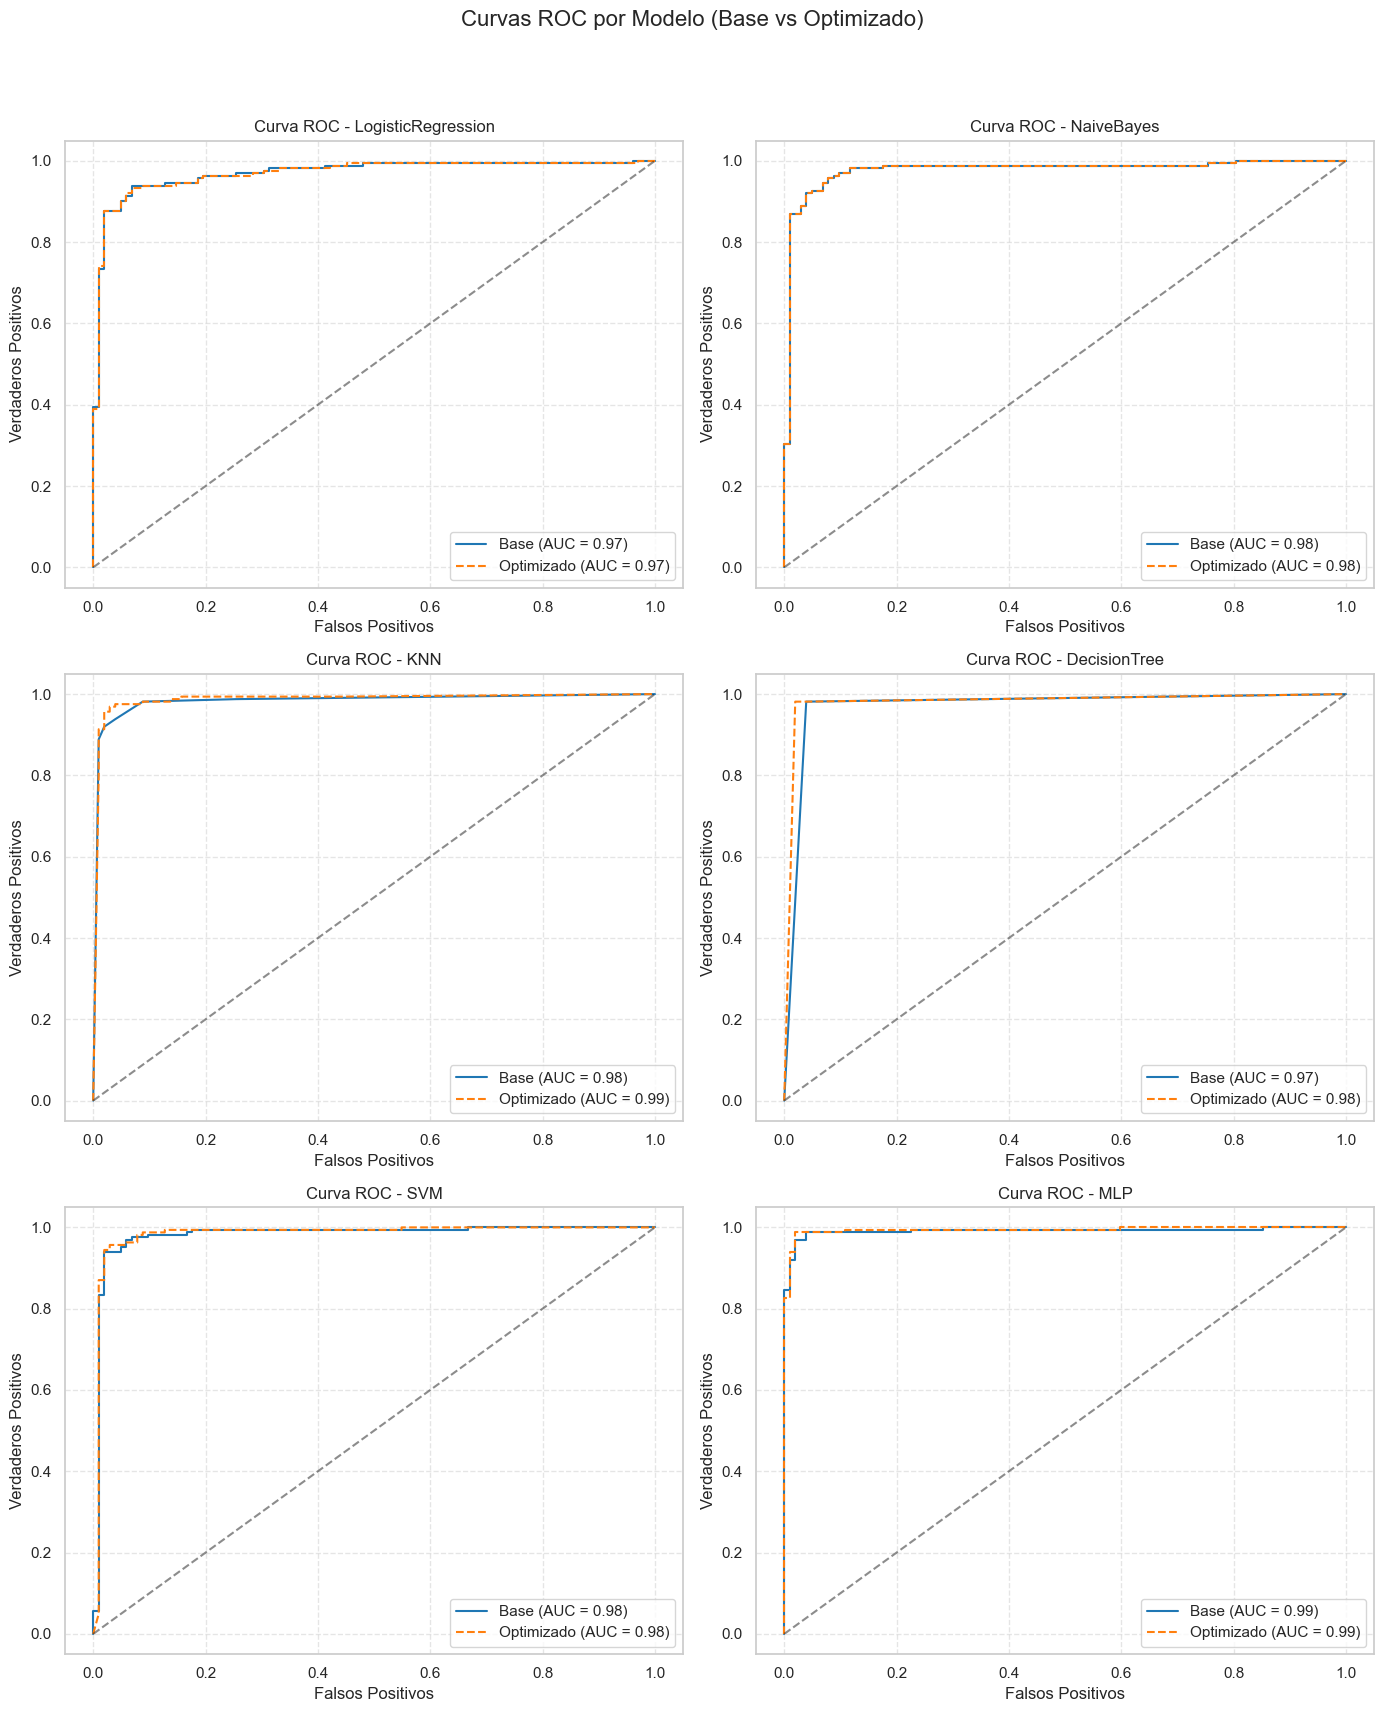

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

modelos = df_resultados_test['Modelo'].unique()

# Crear figura con 2 columnas y 3 filas
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))
axes = axes.flatten()  # Aplanar para poder iterar fácilmente

for i, modelo in enumerate(modelos):
    ax = axes[i]
    modelo_base = modelos_base[modelo]
    modelo_opt = modelos_optimizados[modelo]

    tiene_base = hasattr(modelo_base, "predict_proba")
    tiene_opt = hasattr(modelo_opt, "predict_proba")

    if tiene_base:
        y_prob_base = modelo_base.predict_proba(X_test)[:, 1]
        fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
        auc_base = auc(fpr_base, tpr_base)
        ax.plot(fpr_base, tpr_base, label=f'Base (AUC = {auc_base:.2f})', color='tab:blue')
    
    if tiene_opt:
        y_prob_opt = modelo_opt.predict_proba(X_test)[:, 1]
        fpr_opt, tpr_opt, _ = roc_curve(y_test, y_prob_opt)
        auc_opt = auc(fpr_opt, tpr_opt)
        ax.plot(fpr_opt, tpr_opt, linestyle='--', label=f'Optimizado (AUC = {auc_opt:.2f})', color='tab:orange')

    if tiene_base or tiene_opt:
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_title(f'Curva ROC - {modelo}')
        ax.set_xlabel('Falsos Positivos')
        ax.set_ylabel('Verdaderos Positivos')
        ax.legend(loc='lower right')
        ax.grid(True, linestyle='--', alpha=0.5)
    else:
        ax.set_title(f'{modelo} - No tiene predict_proba')
        ax.axis('off')

# Si hay menos de 6 modelos, desactiva los ejes sobrantes
for j in range(len(modelos), len(axes)):
    axes[j].axis('off')

plt.suptitle("Curvas ROC por Modelo (Base vs Optimizado)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Elegir y exportar los mejores modelos

In [52]:
# Seleccionar el mejor por F1 Score
mejores_modelos = []

for modelo in df_resultados_test['Modelo'].unique():
    subset = df_resultados_test[df_resultados_test['Modelo'] == modelo]
    mejor_fila = subset.loc[subset['F1 Score'].idxmax()]
    mejores_modelos.append(mejor_fila)

# Creamos un dataframe limpio con los seleccionados
df_mejores_modelos = pd.DataFrame(mejores_modelos).reset_index(drop=True)
print(df_mejores_modelos)


               Modelo        Tipo  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  LogisticRegression        Base    0.9318     0.9500  0.9383    0.9441   0.9691
1          NaiveBayes        Base    0.9356     0.9677  0.9259    0.9464   0.9768
2                 KNN  Optimizado    0.9583     0.9871  0.9444    0.9653   0.9867
3        DecisionTree  Optimizado    0.9773     0.9815  0.9815    0.9815   0.9808
4                 SVM  Optimizado    0.9508     0.9627  0.9568    0.9598   0.9834
5                 MLP  Optimizado    0.9848     0.9877  0.9877    0.9877   0.9936


In [17]:
import joblib

# crear carperta modelos si no existe
if not os.path.exists('modelos'):
    os.makedirs('modelos')
    
for idx, row in df_mejores_modelos.iterrows():
    modelo_nombre = row['Modelo']
    tipo = row['Tipo']
    
    if tipo == 'Base':
        modelo_seleccionado = modelos_base[modelo_nombre]
    else:
        modelo_seleccionado = modelos_optimizados[modelo_nombre]
    
    # Guardamos el modelo en disco en la carpeta modelos
    filename = os.path.join('modelos', f"modelo_{modelo_nombre}_{tipo}.pkl")
    joblib.dump(modelo_seleccionado, filename)
    print(f"Modelo {modelo_nombre} ({tipo}) exportado como {filename}")


Modelo LogisticRegression (Base) exportado como modelos\modelo_LogisticRegression_Base.pkl
Modelo NaiveBayes (Base) exportado como modelos\modelo_NaiveBayes_Base.pkl
Modelo KNN (Optimizado) exportado como modelos\modelo_KNN_Optimizado.pkl
Modelo DecisionTree (Optimizado) exportado como modelos\modelo_DecisionTree_Optimizado.pkl
Modelo SVM (Optimizado) exportado como modelos\modelo_SVM_Optimizado.pkl
Modelo MLP (Optimizado) exportado como modelos\modelo_MLP_Optimizado.pkl


In [18]:
df_mejores_modelos.to_csv('mejores_modelos_metricas.csv', index=False)